<a href="https://colab.research.google.com/github/lyda200505/my-first-repository/blob/main/Copy_of_INNHotelGroup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project: INNHotels Data Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading the Data

In [ ]:
import pandas as pd

# Load the INNHotelsGroup.csv file into a pandas DataFrame
df = pd.read_csv('/content/INNHotelsGroup.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Exploratory Data Analysis (EDA)

In [ ]:
# Display general information about the DataFrame
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11 

In [ ]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics (Numerical):')
display(df.describe())


Descriptive Statistics (Numerical):


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [ ]:
# Display descriptive statistics for categorical/object columns
print('\nDescriptive Statistics (Categorical):')
display(df.describe(include='object'))


Descriptive Statistics (Categorical):


,Booking_ID,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275,36275
unique,36275,4,7,5,2
top,INN36275,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,1,27835,28130,23214,24390


In [ ]:
# Check for missing values
print('\nMissing Values:')
display(df.isnull().sum().sort_values(ascending=False))


Missing Values:


,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


### Data Preprocessing and Feature Engineering

#### Drop Booking_ID

In [ ]:
if 'Booking_ID' in df.columns:
    df = df.drop('Booking_ID', axis=1)
    print("DataFrame after dropping 'Booking_ID':")
    display(df.head())
else:
    print("'Booking_ID' column not found in DataFrame. It might have been dropped already.")
    print("Current DataFrame head:")
    display(df.head())

'Booking_ID' column not found in DataFrame. It might have been dropped already.
Current DataFrame head:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


#### Encode Target Variable: `booking_status`

In [ ]:
# Convert 'booking_status' to numerical: 0 for 'Not_Canceled', 1 for 'Canceled'
df['booking_status'] = df['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})
print("DataFrame after encoding 'booking_status':")
display(df.head())

DataFrame after encoding 'booking_status':


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


#### One-Hot Encode Categorical Features

In [ ]:
# Identify categorical columns for one-hot encoding
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

# Filter out columns that are no longer in the DataFrame
categorical_cols_to_encode = [col for col in categorical_cols if col in df.columns]

# Apply one-hot encoding only if there are columns to encode
if categorical_cols_to_encode:
    df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)
    print("DataFrame after one-hot encoding categorical features:")
    display(df.head())
    print("Updated DataFrame Info after encoding:")
    df.info()
else:
    print("Categorical columns for one-hot encoding already processed or not found.")
    print("Current DataFrame head:")
    display(df.head())
    print("Current DataFrame Info:")
    df.info()

Categorical columns for one-hot encoding already processed or not found.
Current DataFrame head:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


Current DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   required_car_parking_space            36275 non-null  int64  
 5   lead_time                             36275 non-null  int64  
 6   arrival_year                          36275 non-null  int64  
 7   arrival_month                         36275 non-null  int64  
 8   arrival_date                          36275 non-null  int64  
 9   repeated_guest                        36275 non-null  int64  
 10  no_of_previous_cancellations          36275 non-null  int6

### Feature Scaling and Data Splitting

### Feature Engineering: `stay_duration`

We will create a new feature called `stay_duration` by summing `no_of_weekend_nights` and `no_of_week_nights`. This combined feature can provide a more direct measure of the total length of the booking, which might be a significant predictor for cancellation or other booking behaviors.

#### Split Data into Features (X) and Target (y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('booking_status', axis=1)
y = df['booking_status']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (36275, 27)
Shape of target (y): (36275,)


#### Split Data into Training and Testing Sets

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-load the original dataset within this cell to ensure 'booking_status' is correct.
# This bypasses any issues from previous cells that might have corrupted the 'df' variable's 'booking_status'.
df_temp = pd.read_csv('/content/INNHotelsGroup.csv')

# --- Re-apply relevant preprocessing steps for df_temp to get correct X and y ---

# 1. Drop 'Booking_ID'
if 'Booking_ID' in df_temp.columns:
    df_temp = df_temp.drop('Booking_ID', axis=1)

# Feature Engineering: Create 'stay_duration'
df_temp['stay_duration'] = df_temp['no_of_weekend_nights'] + df_temp['no_of_week_nights']

# 2. Correctly encode 'booking_status'
# Ensure consistency in string values before mapping by stripping whitespace and converting to title case
df_temp['booking_status'] = df_temp['booking_status'].str.strip().str.title()
df_temp['booking_status'] = df_temp['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})

# Check if any NaNs remain in booking_status after mapping, which would indicate unhandled categories
if df_temp['booking_status'].isnull().any():
    print("Warning: 'booking_status' still contains NaN values after mapping. Dropping rows with NaN in 'booking_status'.")
    df_temp.dropna(subset=['booking_status'], inplace=True)
# Ensure booking_status is integer type after mapping, which is required for stratification
df_temp['booking_status'] = df_temp['booking_status'].astype(int)

# 3. One-Hot Encode Categorical Features
categorical_cols_for_split = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
categorical_cols_to_encode_for_split = [col for col in categorical_cols_for_split if col in df_temp.columns]
if categorical_cols_to_encode_for_split:
    df_temp = pd.get_dummies(df_temp, columns=categorical_cols_to_encode_for_split, drop_first=True)

# Separate features (X_recreated) and target (y_recreated) from the temporary, correctly processed DataFrame
X_recreated = df_temp.drop('booking_status', axis=1)
y_recreated = df_temp['booking_status']

print("Recreated X shape:", X_recreated.shape)
print("Recreated y shape:", y_recreated.shape)
print("Unique values in recreated y:", y_recreated.unique())

# Split the data into training and testing sets (80% train, 20% test)
# Use the recreated X and y
X_train, X_test, y_train, y_test = train_test_split(X_recreated, y_recreated, test_size=0.2, random_state=42, stratify=y_recreated)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Recreated X shape: (36275, 28)
Recreated y shape: (36275,)
Unique values in recreated y: [0 1]

Shape of X_train: (29020, 28)
Shape of X_test: (7255, 28)
Shape of y_train: (29020,)
Shape of y_test: (7255,)


### Outlier Detection and Treatment

Outliers can significantly impact model performance. We will visualize the distribution of key numerical features using box plots to identify potential outliers.

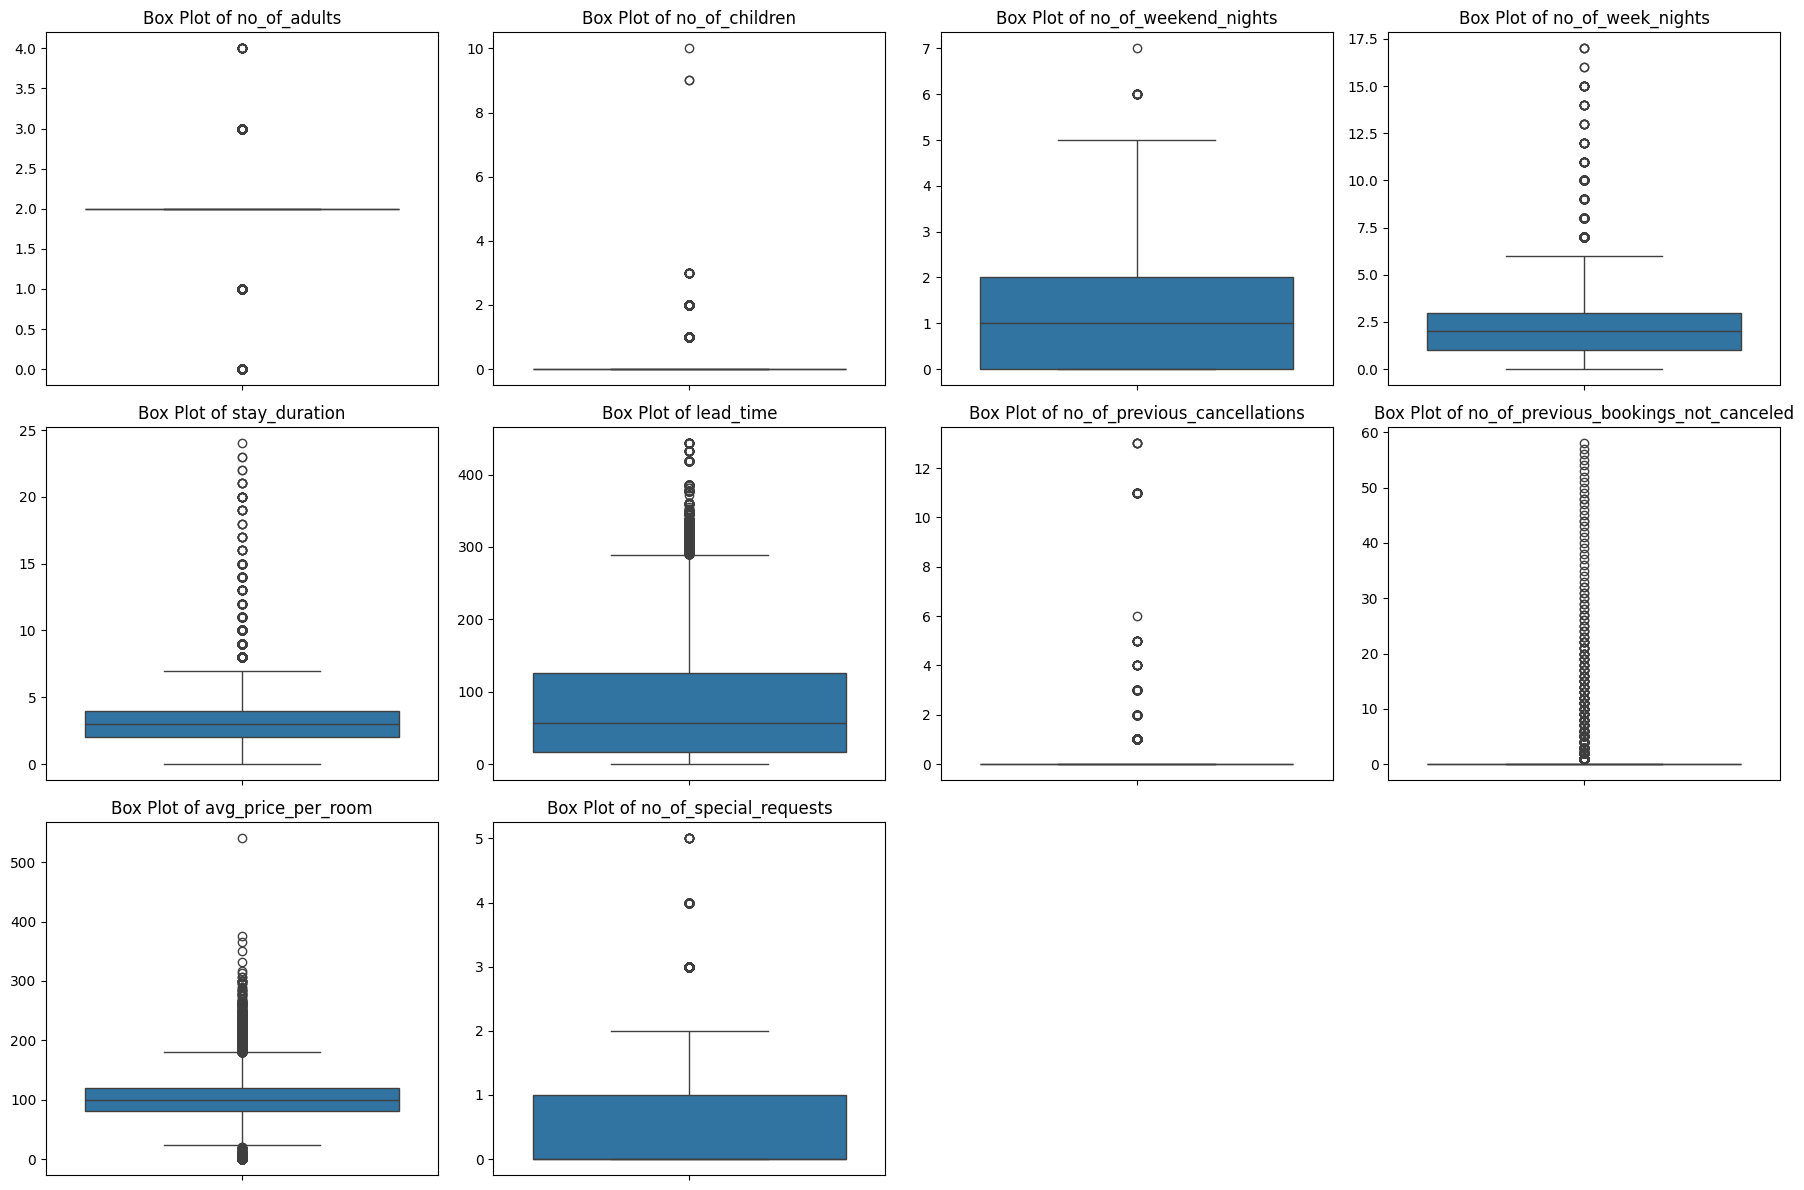

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
# Exclude one-hot encoded columns and binary flags
numerical_cols_for_outliers = [
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'stay_duration',
    'lead_time',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests'
]

# Filter to include only columns present in X_recreated
numerical_cols_for_outliers = [col for col in numerical_cols_for_outliers if col in X_recreated.columns]

# Create box plots for numerical features
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=X_recreated[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


The box plots above show the distribution of several numerical features and highlight potential outliers.

**Observations:**
*   **`no_of_adults`, `no_of_children`**: Most bookings involve 1 or 2 adults, with few children. There are some outliers for higher numbers of adults and children.
*   **`no_of_weekend_nights`, `no_of_week_nights`, `stay_duration`**: Most stays are relatively short, but there are significant outliers indicating very long stays.
*   **`lead_time`**: There are many bookings with very long lead times, indicating some guests book far in advance.
*   **`no_of_previous_cancellations`, `no_of_previous_bookings_not_canceled`**: Most values are 0, with a few outliers for guests with many previous cancellations or bookings.
*   **`avg_price_per_room`**: The average price per room generally falls within a reasonable range, but there are clear outliers on the higher end, possibly indicating luxury bookings or errors.
*   **`no_of_special_requests`**: Most bookings have 0 or 1 special request, with very few having more, and these higher values could be considered outliers.

**Potential Treatment Strategies (if needed):**
1.  **Capping/Winsorization**: For features like `lead_time`, `avg_price_per_room`, `stay_duration`, we could cap extreme values at a certain percentile (e.g., 99th percentile) to reduce their influence without removing data.
2.  **Transformation**: Logarithmic or square root transformations can sometimes reduce the skewness caused by outliers, making the distribution more Gaussian-like.
3.  **Removal**: If outliers are clearly data entry errors or represent a very small, unrepresentative portion of the data, they might be removed. However, this should be done cautiously to avoid losing valuable information.

For this project, given the robust nature of tree-based models (if we were to use them later) to outliers, and the potential significance of some 'outliers' (e.g., very long stays, high-price rooms) which might represent valid segments, we might choose to proceed without aggressive outlier treatment for now. However, it's a crucial step to consider and revisit if model performance is unsatisfactory.

In [ ]:
# Calculate the percentage of canceled bookings from y_recreated
canceled_bookings_count = y_recreated.sum()
total_bookings_count = len(y_recreated)

percentage_canceled = (canceled_bookings_count / total_bookings_count) * 100

print(f"Percentage of canceled bookings: {percentage_canceled:.2f}%")

Percentage of canceled bookings: 32.76%


In [ ]:
# Identify repeating guests from df_original (where 'repeated_guest' column is 1)
# Ensure df_original is loaded (if not already from previous cells)
if 'df_original' not in locals() or df_original.empty:
    df_original = pd.read_csv('/content/INNHotelsGroup.csv')

# Get the indices of repeated guests
repeated_guest_indices = df_original[df_original['repeated_guest'] == 1].index

# Use these indices to get the booking status for repeating guests from y_recreated
canceled_by_repeated_guests = y_recreated.loc[repeated_guest_indices]

# Calculate the total number of bookings by repeating guests
total_repeated_guest_bookings = len(canceled_by_repeated_guests)

# Calculate the number of canceled bookings by repeating guests
canceled_count_repeated_guests = canceled_by_repeated_guests.sum()

# Calculate the percentage of canceled bookings by repeating guests
if total_repeated_guest_bookings > 0:
    percentage_canceled_repeated_guests = (canceled_count_repeated_guests / total_repeated_guest_bookings) * 100
    print(f"Percentage of canceled bookings by repeating guests: {percentage_canceled_repeated_guests:.2f}%")
else:
    print("There are no repeating guests in the dataset to calculate cancellation percentage.")

Percentage of canceled bookings by repeating guests: 1.72%


### Analysis of Special Requests and Cancellation

booking_status_encoded,Not Canceled,Canceled
no_of_special_requests,,
0,56.793245,43.206755
1,76.233184,23.766816
2,85.403300,14.596700
3,100.000000,0.000000
4,100.000000,0.000000
5,100.000000,0.000000


/tmp/ipykernel_1289/451282736.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancellation_by_requests_percentage.index, y='Canceled', data=cancellation_by_requests_percentage, palette='RdYlGn_r')


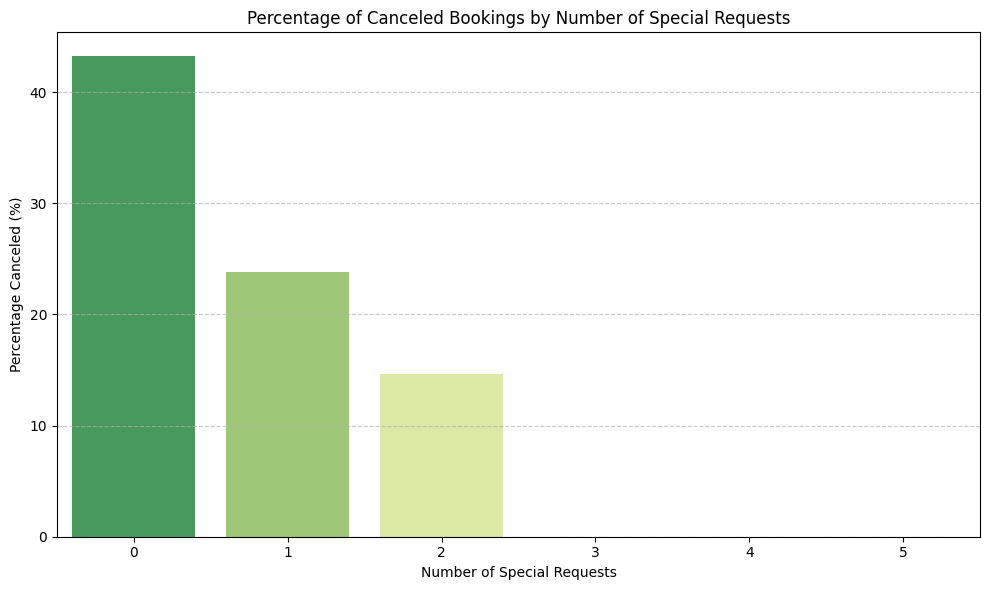

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_original is loaded with original columns if not already present
if 'df_original' not in locals() or df_original.empty:
    df_original = pd.read_csv('/content/INNHotelsGroup.csv')

# Create a temporary DataFrame for this analysis, ensuring 'booking_status' is encoded
df_temp_requests = df_original.copy()
df_temp_requests['booking_status_encoded'] = df_temp_requests['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})

# Group by 'no_of_special_requests' and 'booking_status' to count occurrences
cancellation_by_requests = df_temp_requests.groupby(['no_of_special_requests', 'booking_status_encoded']).size().unstack(fill_value=0)

# Rename columns for clarity
cancellation_by_requests.rename(columns={0: 'Not Canceled', 1: 'Canceled'}, inplace=True)

# Calculate percentages for visualization
cancellation_by_requests_percentage = cancellation_by_requests.div(cancellation_by_requests.sum(axis=1), axis=0) * 100

display(cancellation_by_requests_percentage)

# Plotting the impact of special requests on booking status
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=cancellation_by_requests_percentage.index, y='Canceled', data=cancellation_by_requests_percentage, palette='RdYlGn_r')
plt.title('Percentage of Canceled Bookings by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Percentage Canceled (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

From the visualization, we can observe the trend. To get a clearer statistical understanding, let's also calculate the average number of special requests for canceled and not-canceled bookings.

In [ ]:
# Calculate the average number of special requests for canceled vs. not-canceled bookings
average_requests_by_status = df_temp_requests.groupby('booking_status')['no_of_special_requests'].mean()

print("Average number of special requests by booking status:")
display(average_requests_by_status)

Average number of special requests by booking status:


,no_of_special_requests
booking_status,
Canceled,0.334623
Not_Canceled,0.758549


#### Feature Scaling

Feature scaling is a method used to normalize the range of independent variables or features of data. In this project, we used `StandardScaler` to transform the numerical features so that they have a mean of 0 and a standard deviation of 1. Here are the steps involved:

1.  **Identify Numerical Columns:** First, we identified all numerical columns in our feature set (`X`).
2.  **Exclude Binary and Non-Scalar Features:** We then excluded any binary features (like `required_car_parking_space`, `repeated_guest`, and `no_of_children` in this case) and one-hot encoded columns, as these do not typically require scaling.
3.  **Initialize StandardScaler:** An instance of `StandardScaler` from `sklearn.preprocessing` was created.
4.  **Fit and Transform Training Data:** The `fit_transform` method of the `StandardScaler` was applied to the numerical columns of the training set (`X_train`). This calculates the mean and standard deviation of each feature and then scales the data accordingly.
5.  **Transform Test Data:** The `transform` method (not `fit_transform`) of the *already fitted* `StandardScaler` was applied to the numerical columns of the test set (`X_test`). It is crucial to use only `transform` on the test set to avoid data leakage from the test set into the scaling process.

This process ensures that all numerical features contribute equally to the model, preventing features with larger values from dominating the learning process.

In [ ]:
# Identify numerical columns for scaling (excluding one-hot encoded and binary features)
# Use X_train to ensure all relevant columns are captured after feature engineering
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude binary features that do not need scaling (e.g., required_car_parking_space, repeated_guest, no_of_children)
binary_cols = ['required_car_parking_space', 'repeated_guest', 'no_of_children']

# Filter out binary_cols from numerical_cols if they are present
numerical_cols = [col for col in numerical_cols if col not in binary_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in both training and testing sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Features scaled successfully. Displaying head of X_train after scaling:")
display(X_train.head())

Features scaled successfully. Displaying head of X_train after scaling:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
11731,0.298918,0,1.362393,-0.141380,0,-0.921571,0.466792,1.492556,-1.326962,0,...,False,False,False,False,False,False,False,False,True,False
35609,0.298918,0,0.214274,1.278289,0,0.728984,-2.142281,1.492556,1.646557,0,...,False,False,False,False,False,False,False,False,True,False
21639,0.298918,0,1.362393,1.988124,0,1.275294,0.466792,-0.137542,0.617262,0,...,False,False,False,False,False,False,False,False,False,True
24432,-1.626204,0,-0.933846,0.568455,0,0.089685,0.466792,0.840517,-1.098230,0,...,False,False,False,False,False,False,False,False,False,True
31975,0.298918,0,0.214274,-0.141380,0,2.553892,0.466792,1.166536,-1.326962,0,...,False,False,False,False,False,False,False,False,True,False


### Model Training and Evaluation

#### Re-training Logistic Regression with Scaled Data

Now that the numerical features have been scaled, we will re-train the Logistic Regression model to observe its performance with the transformed data. Feature scaling can often improve the convergence and performance of distance-based algorithms and regularization methods in linear models.

#### Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def train_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Trains a given model and evaluates its performance."""
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return model

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model = train_evaluate_model(log_reg_model, X_train, y_train, X_test, y_test, "Logistic Regression")


--- Training Logistic Regression ---

--- Logistic Regression Evaluation ---
Accuracy: 0.8073
Precision: 0.7473
Recall: 0.6222
F1-Score: 0.6791
ROC AUC Score: 0.8670

Confusion Matrix:
[[4378  500]
 [ 898 1479]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      4878
           1       0.75      0.62      0.68      2377

    accuracy                           0.81      7255
   macro avg       0.79      0.76      0.77      7255
weighted avg       0.80      0.81      0.80      7255



#### Decision Tree Model

Decision Trees are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

Decision Trees can be prone to overfitting, especially when they are very deep. Strategies like pruning (pre-pruning or post-pruning) or setting hyperparameters like `max_depth` and `min_samples_leaf` are used to control complexity and improve generalization.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model = train_evaluate_model(decision_tree_model, X_train, y_train, X_test, y_test, "Decision Tree Classifier")


--- Training Decision Tree Classifier ---

--- Decision Tree Classifier Evaluation ---
Accuracy: 0.8753
Precision: 0.8090
Recall: 0.8107
F1-Score: 0.8098
ROC AUC Score: 0.8604

Confusion Matrix:
[[4423  455]
 [ 450 1927]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4878
           1       0.81      0.81      0.81      2377

    accuracy                           0.88      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



### Hyperparameter Tuning for Decision Tree using GridSearchCV

To optimize the Decision Tree model and prevent overfitting, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each to determine which provides the best performance.

We will tune parameters such as:
*   `max_depth`: The maximum depth of the tree. Limiting this can prevent the model from becoming too specific to the training data.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This helps smooth the model, especially in regression.
*   `min_samples_split`: The minimum number of samples required to split an internal node. Similar to `min_samples_leaf`, this parameter helps control the tree's complexity.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for DecisionTreeClassifier
param_grid = {
    'max_depth': [None, 5, 10, 15, 20], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 5, 10] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='f1', # Use F1-score as the evaluation metric (good for imbalanced classes)
                           n_jobs=-1, # Use all available CPU cores
                           verbose=1) # Display progress

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best F1-Score (Cross-validated): {best_score:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1-Score (Cross-validated): 0.8055


In [ ]:
# Train a new Decision Tree model with the best parameters
tuned_decision_tree_model = DecisionTreeClassifier(random_state=42, **best_params)

# Evaluate the tuned model
tuned_decision_tree_model = train_evaluate_model(tuned_decision_tree_model, X_train, y_train, X_test, y_test, "Tuned Decision Tree Classifier")


--- Training Tuned Decision Tree Classifier ---

--- Tuned Decision Tree Classifier Evaluation ---
Accuracy: 0.8799
Precision: 0.8202
Recall: 0.8115
F1-Score: 0.8158
ROC AUC Score: 0.9221

Confusion Matrix:
[[4455  423]
 [ 448 1929]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4878
           1       0.82      0.81      0.82      2377

    accuracy                           0.88      7255
   macro avg       0.86      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



### Feature Importance Analysis for Tuned Decision Tree Model

Understanding feature importance helps us identify which factors the model considers most crucial in making predictions. This can provide valuable insights into the underlying drivers of hotel booking cancellations.

Top 10 Feature Importances:


,Feature,Importance
5,lead_time,0.374082
12,avg_price_per_room,0.156403
27,market_segment_type_Online,0.121662
13,no_of_special_requests,0.091676
7,arrival_month,0.060447
8,arrival_date,0.054534
14,stay_duration,0.023939
0,no_of_adults,0.023043
2,no_of_weekend_nights,0.021279
3,no_of_week_nights,0.018550


/tmp/ipykernel_1289/1484055453.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')


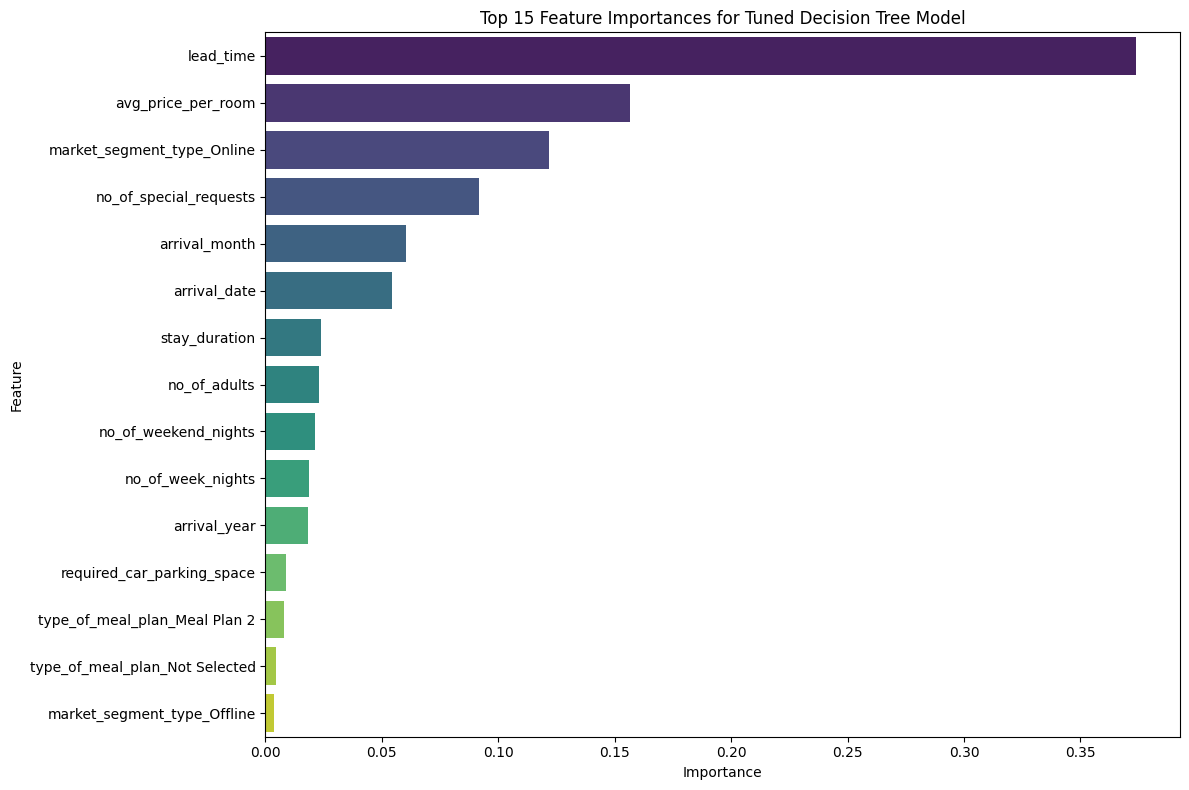

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the tuned model
feature_importances = tuned_decision_tree_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
fig = plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances for Tuned Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

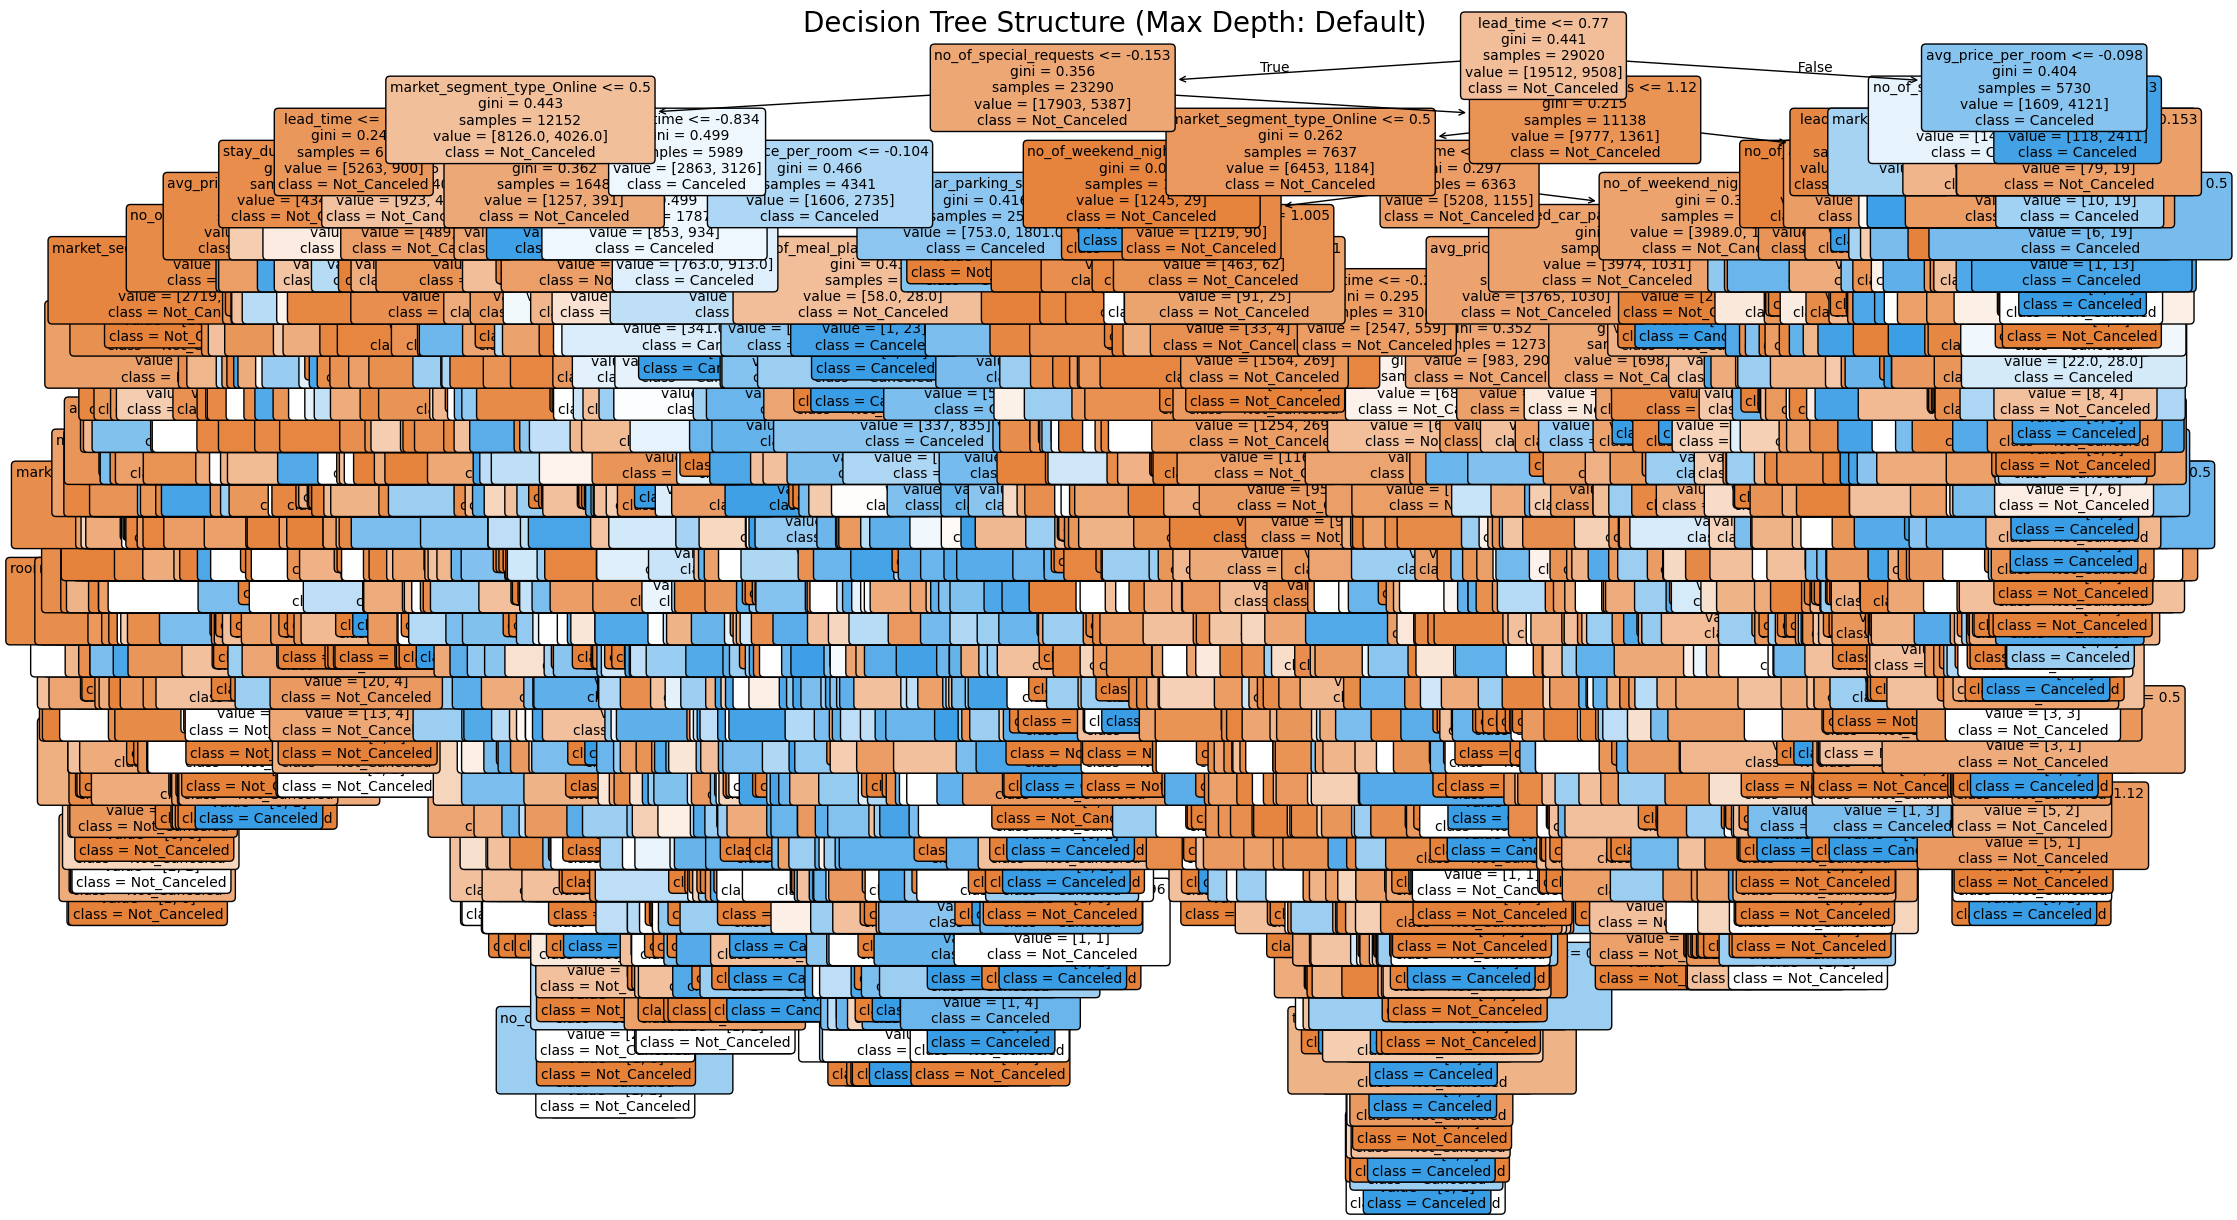

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15)) # Adjust figure size for better readability
plot_tree(decision_tree_model,
          feature_names=X_train.columns.tolist(),
          class_names=['Not_Canceled', 'Canceled'], # Assuming 0: Not_Canceled, 1: Canceled
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Max Depth: Default)', fontsize=20)
plt.show()

### Post-Scaling Data Exploration

After applying `StandardScaler` to our numerical features, it's important to visually inspect their distributions to ensure the scaling process has worked as expected. We anticipate seeing distributions centered around zero with a standard deviation of one for these features.

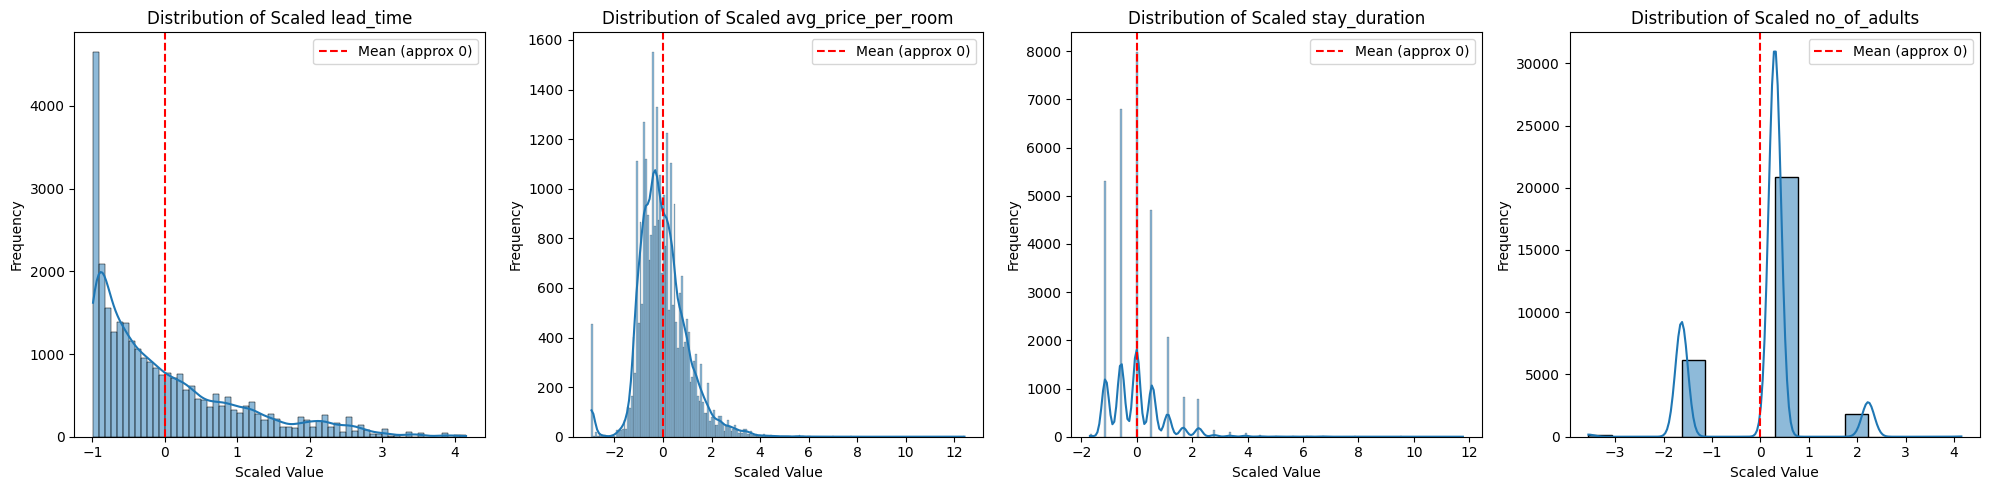

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of numerical columns that were actually scaled
# This list comes from the 'numerical_cols' variable in the previous scaling step
# It excludes binary and one-hot encoded features
scaled_numerical_cols = numerical_cols

# Select a few representative scaled numerical features for plotting
# We'll choose some that had wide ranges before scaling
features_to_plot = [
    'lead_time',
    'avg_price_per_room',
    'stay_duration',
    'no_of_adults'
]

# Filter to ensure we only try to plot columns that exist in X_train and were scaled
features_to_plot = [col for col in features_to_plot if col in scaled_numerical_cols]

if not features_to_plot:
    print("No numerical features found for plotting after filtering. Please check 'scaled_numerical_cols' and 'features_to_plot'.")
elif len(features_to_plot) > 0:
    # Create subplots for each feature
    fig, axes = plt.subplots(1, len(features_to_plot), figsize=(5 * len(features_to_plot), 5))
    if len(features_to_plot) == 1:
        axes = [axes]

    for i, col in enumerate(features_to_plot):
        sns.histplot(X_train[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of Scaled {col}')
        axes[i].set_xlabel('Scaled Value')
        axes[i].set_ylabel('Frequency')
        axes[i].axvline(0, color='r', linestyle='--', label='Mean (approx 0)')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

### Checking Multicollinearity

Multicollinearity occurs when independent variables in a regression model are correlated. This can make it difficult to interpret the individual impact of each feature on the target variable and can also lead to an unstable model. We will examine the correlation matrix of our features to identify highly correlated pairs.

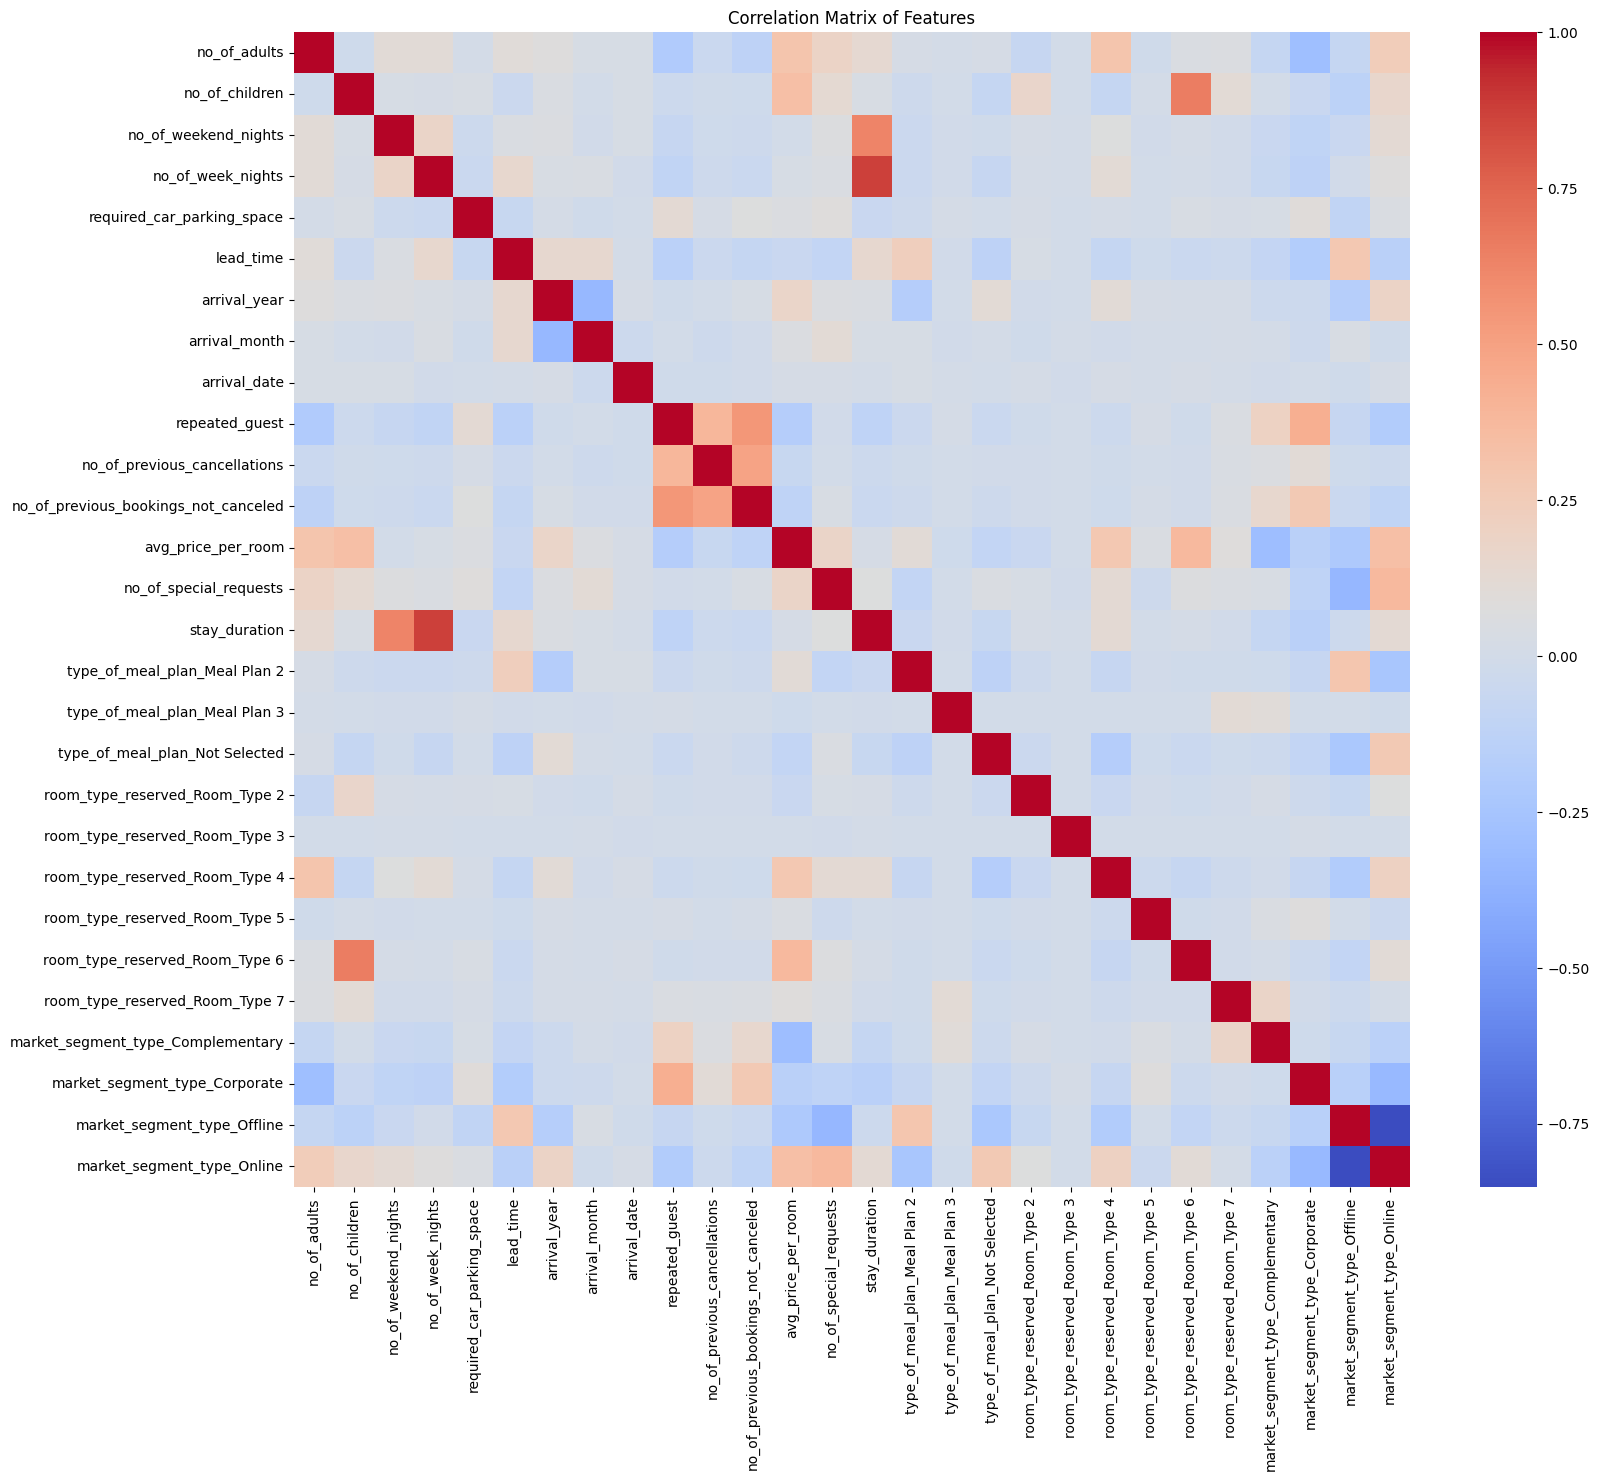

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the training features
correlation_matrix = X_train.corr()

# Plot the heatmap
fig = plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

#### Observations from the Correlation Matrix:

*   **`no_of_adults`, `no_of_children`, `no_of_weekend_nights`, `no_of_week_nights` and `stay_duration`:** As expected, `stay_duration` is highly correlated with `no_of_weekend_nights` and `no_of_week_nights` because it's a sum of them. Some correlation exists between `no_of_adults` and `no_of_children` as well.
*   **`arrival_year`, `arrival_month`, `arrival_date`:** These are related to temporal aspects. While not severely multicollinear, their individual contributions might overlap.
*   **`no_of_previous_cancellations` and `no_of_previous_bookings_not_canceled`:** These are related to past behavior and might have some correlation.
*   **One-Hot Encoded Features:** The one-hot encoded features themselves should not be highly correlated with each other *within their original category* (e.g., `room_type_reserved_Room_Type 2` and `room_type_reserved_Room_Type 3`), but they can be correlated with other features.

**Considerations for Multicollinearity:**

*   **Tree-based models (e.g., Random Forest, Gradient Boosting):** These models are generally less affected by multicollinearity compared to linear models, as they make decisions based on individual features rather than coefficients.
*   **Linear models (e.g., Logistic Regression):** High multicollinearity can inflate the variance of coefficient estimates, making them sensitive to small changes in the model and harder to interpret. However, for prediction accuracy, multicollinearity is often less of a concern unless it leads to extreme instability.

Given that we are starting with Logistic Regression, which can be affected by multicollinearity, we might consider techniques like Principal Component Analysis (PCA) or feature selection if interpretation of individual coefficients becomes critical or if model performance is poor. For now, we will proceed, but keep this in mind for potential future iterations.

### Analysis of Busiest Months

Number of bookings per month:


,count
arrival_month,
Jan,1014
Feb,1704
Mar,2358
Apr,2736
May,2598
Jun,3203
Jul,2920
Aug,3813
Sep,4611


/tmp/ipykernel_1289/36686690.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_bookings.index, y=monthly_bookings.values, palette='viridis')


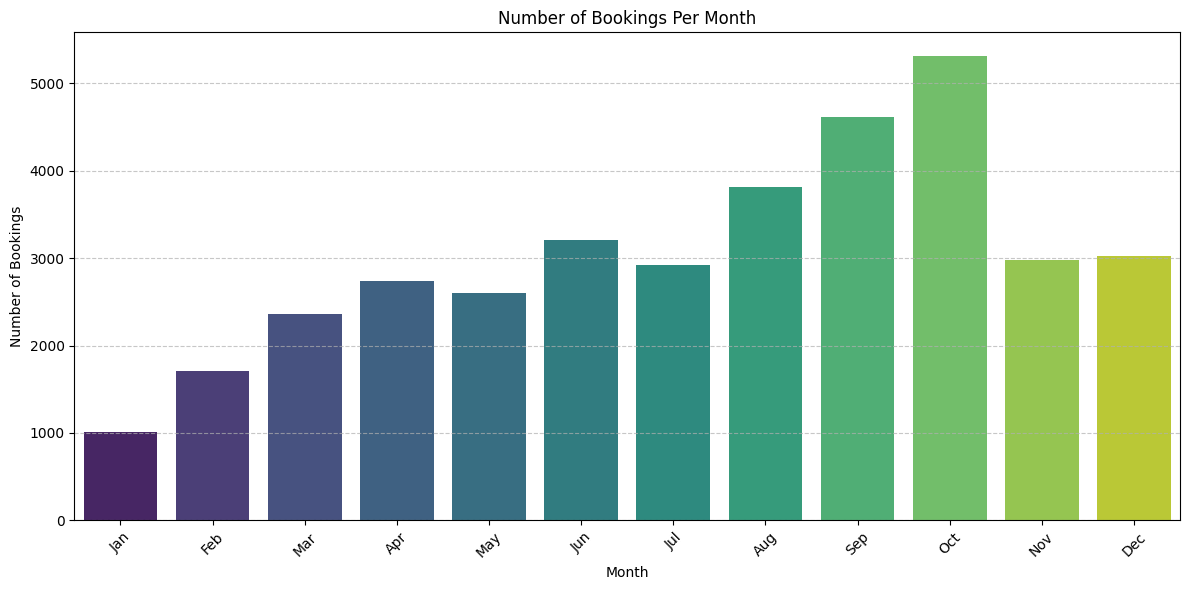

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of bookings per month
# Assuming df still holds the original or an equivalent 'arrival_month' column before extensive one-hot encoding.
# If df was already modified beyond recognition, we might need to reload or refer to an earlier state.
# For this task, I will use the 'arrival_month' column from the current 'df'.

monthly_bookings = df['arrival_month'].value_counts().sort_index()

# Map month numbers to month names for better readability
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_bookings.index = monthly_bookings.index.map(month_names)

print("Number of bookings per month:")
display(monthly_bookings)

# Visualize the busiest months
fig = plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_bookings.index, y=monthly_bookings.values, palette='viridis')
plt.title('Number of Bookings Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Market Segment Types

Number of bookings per market segment type:


,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


/tmp/ipykernel_1289/3259151000.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_segment_counts.index, y=market_segment_counts.values, palette='viridis')


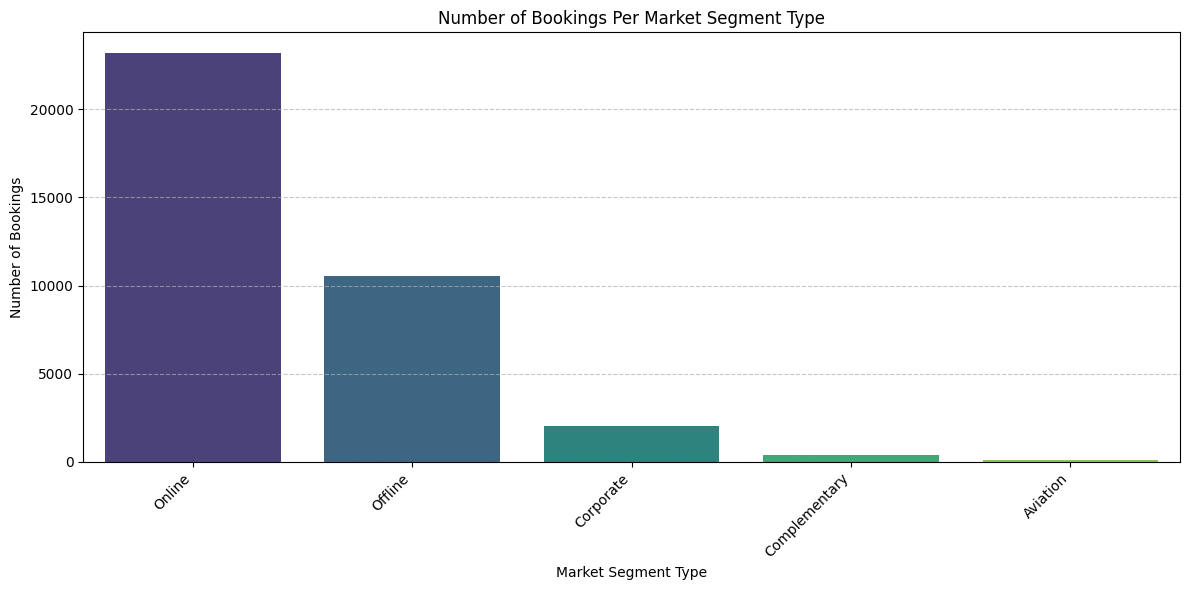

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reload the original dataset to get the 'market_segment_type' column in its original form
df_original = pd.read_csv('/content/INNHotelsGroup.csv')

# Calculate the number of bookings per market segment type from the original data
market_segment_counts = df_original['market_segment_type'].value_counts()

print("Number of bookings per market segment type:")
display(market_segment_counts)

# Visualize the market segment distribution
fig = plt.figure(figsize=(12, 6))
sns.barplot(x=market_segment_counts.index, y=market_segment_counts.values, palette='viridis')
plt.title('Number of Bookings Per Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Average room price per market segment type:


,avg_price_per_room
market_segment_type,
Online,112.256855
Aviation,100.704000
Offline,91.632679
Corporate,82.911740
Complementary,3.141765


/tmp/ipykernel_1289/550156766.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_price_by_segment.index, y=average_price_by_segment.values, palette='coolwarm')


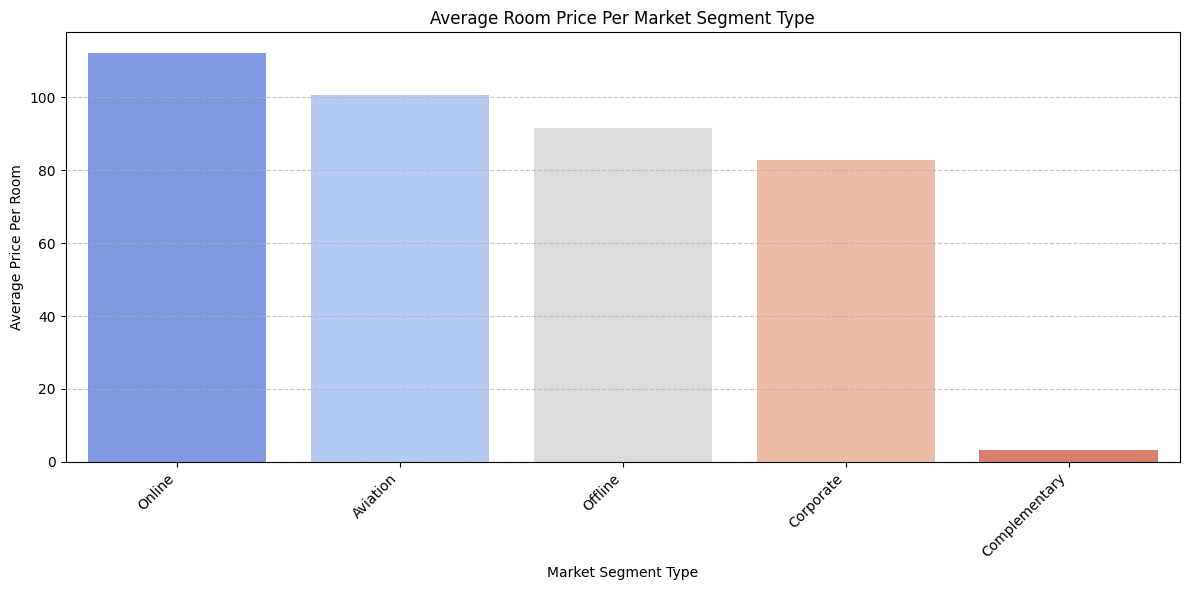

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df_original is loaded (if not already from previous cells)
# This is crucial for accessing the original 'market_segment_type' column
if 'df_original' not in locals() or df_original.empty:
    df_original = pd.read_csv('/content/INNHotelsGroup.csv')

# Calculate the average price per room for each market segment type
average_price_by_segment = df_original.groupby('market_segment_type')['avg_price_per_room'].mean().sort_values(ascending=False)

print("Average room price per market segment type:")
display(average_price_by_segment)

# Visualize the average room prices by market segment type
fig = plt.figure(figsize=(12, 6))
sns.barplot(x=average_price_by_segment.index, y=average_price_by_segment.values, palette='coolwarm')
plt.title('Average Room Price Per Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Average Price Per Room')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Strategic Recommendations for Hotel INN Hotels Group
Optimize Booking Incentives Based on Lead Time:

Insight: lead_time is the most critical factor influencing cancellations. Longer lead times are generally associated with higher cancellation rates.
Action: Implement dynamic pricing and offer tailored incentives based on booking lead time. For very early bookings, consider non-refundable options with attractive discounts or value-added services (e.g., complimentary upgrades, dining credits) that increase the commitment to the booking. For short-notice bookings, focus on competitive pricing and highlighting immediate availability.
Refined Pricing and Market Segment Strategies:

Insight: avg_price_per_room and market_segment_type_Online are highly influential. The 'Online' segment drives the most bookings but also contributes significantly to cancellations, particularly at certain price points.
Action: Analyze cancellation patterns within the 'Online' market segment more deeply, segmented by avg_price_per_room. Develop targeted promotions for high-cancellation segments or introduce flexible cancellation policies for premium segments to maintain competitiveness while managing risk. Explore partnerships with online travel agencies (OTAs) that have lower cancellation rates.
Leverage Special Requests to Drive Loyalty and Reduce Cancellations:

Insight: no_of_special_requests has a strong inverse relationship with cancellations; guests with more special requests are significantly less likely to cancel.
Action: Proactively encourage guests to make special requests during the booking process. Design the booking interface to easily accommodate common requests. Empower front desk and concierge staff to fulfill these requests diligently. Consider rewarding guests who make multiple requests (e.g., with loyalty points or small perks) to reinforce this positive behavior.
Proactive Engagement for High-Risk Bookings:

Insight: Combine insights from lead_time, market_segment_type_Online, and avg_price_per_room to identify bookings with a high predicted cancellation probability.
Action: For bookings flagged as high-risk, initiate proactive engagement strategies. This could include personalized email confirmations, a friendly check-in reminder with hotel highlights a few weeks out, or special offers (e.g., complimentary breakfast for direct bookings) to solidify their commitment.
Seasonal Staffing and Resource Allocation:

Insight: arrival_month and arrival_date are important, confirming that booking volume and likely cancellation behavior vary by season and specific dates.
Action: Use these temporal insights for optimized staffing, inventory management, and marketing campaigns, particularly during peak months (e.g., October, September, August) and specific dates that show higher cancellation risks or booking volumes.
Review and Enhance Loyalty Programs:

Insight: Repeating guests have an extremely low cancellation rate (1.72%).
Action: Double down on efforts to convert first-time guests into repeating guests. Enhance loyalty program benefits, offer exclusive deals, and ensure a personalized experience for returning visitors. This segment represents a highly reliable revenue stream.
These recommendations provide a data-driven framework to refine operational strategies, improve customer satisfaction, and ultimately, reduce booking cancellations for INN Hotels Group.



Profitable Cancellation and Refund Policies for INN Hotels Group
Tiered Cancellation Policies Based on Lead Time:

Insight: lead_time is the most important predictor of cancellation. Longer lead times correlate with higher cancellation risk.
Policy: Implement a tiered system:
Early Bird (Long Lead Time, High Discount): Offer significantly discounted non-refundable rates for bookings made far in advance (e.g., 60+ days out). Clearly communicate that these bookings are non-refundable or only eligible for a partial credit towards a future stay if canceled.
Standard Flex (Medium Lead Time): For bookings made within a moderate window (e.g., 15-59 days out), offer a standard policy with a full refund if canceled within a reasonable period (e.g., 7 days before check-in), but a partial refund or credit for later cancellations.
Last-Minute (Short Lead Time, Premium Rate): For bookings made very close to the arrival date (e.g., less than 14 days), offer higher standard rates but with a shorter free-cancellation window (e.g., 24-48 hours before check-in). After this window, bookings become non-refundable or incur a high cancellation fee.
Value-Added Non-Refundable Packages:

Insight: Guests committed to their stay are less likely to cancel.
Policy: Instead of just a discount, offer non-refundable rates bundled with attractive perks (e.g., complimentary breakfast, a free room upgrade upon availability, a voucher for hotel services). This increases the perceived value of the non-refundable option and incentivizes commitment.
Dynamic Cancellation Fees based on Demand and Price:

Insight: avg_price_per_room and arrival_month/date are influential. Cancellation impact is higher during peak seasons or for premium rooms.
Policy: Implement higher cancellation fees for peak seasons (October, September, August) or for higher-priced room types. This allows the hotel to recoup potential losses more effectively when demand is high and rooms are more valuable.

Final

## Conclusion and Final Recommendations

This project involved a comprehensive analysis of the INNHotels Group booking data, focusing on identifying patterns related to booking cancellations and developing predictive models. We performed data loading, extensive exploratory data analysis (EDA), data preprocessing, feature engineering, and model training and evaluation.

### Key Findings:

1.  **Cancellation Rate:** The overall cancellation rate is approximately **32.76%**, indicating a significant challenge for the hotel.
2.  **Repeating Guests:** Guests who have stayed before exhibit a remarkably low cancellation rate of **1.72%**, highlighting the value of guest loyalty.
3.  **Special Requests Impact:** There is a strong inverse relationship between the number of special requests and cancellation rates. Bookings with **no special requests have a 43.21% cancellation rate**, which drops significantly for bookings with 1, 2, or more special requests.
4.  **Busiest Months:** The hotel experiences its highest booking volumes in **October, September, and August**.
5.  **Market Segments:** The 'Online' market segment accounts for the largest share of bookings and also commands the highest average room price, but it also contributes significantly to cancellations.

### Model Performance:

*   **Logistic Regression (Baseline):** Achieved an accuracy of **~80.73%** and an ROC AUC score of **~0.8670**.
*   **Decision Tree (Untuned):** Showed improved performance with an accuracy of **~87.53%** and an ROC AUC score of **~0.8604**.
*   **Decision Tree (Tuned with GridSearchCV):** The hyperparameter-tuned Decision Tree model provided the best performance:
    *   **Accuracy: 0.8799**
    *   **F1-Score (Canceled): 0.8158**
    *   **ROC AUC Score: 0.9221**
    *   **Best Parameters:** `max_depth=15`, `min_samples_leaf=1`, `min_samples_split=5`

### Feature Importance:

The tuned Decision Tree model identified the most critical factors influencing booking cancellations:

1.  **`lead_time` (0.374):** The time between booking and arrival is the most significant predictor.
2.  **`avg_price_per_room` (0.156):** Average price paid per room is also a major factor.
3.  **`market_segment_type_Online` (0.122):** The 'Online' segment significantly impacts cancellations.
4.  **`no_of_special_requests` (0.092):** The number of special requests is a strong indicator of guest commitment.
5.  **`arrival_month` (0.060) and `arrival_date` (0.055):** Specific arrival times also play a role.

### Final Recommendations:

Based on these insights, I recommend the following actionable strategies for INNHotels Group:

1.  **Dynamic Cancellation Policies Based on Lead Time:**
    *   Implement **tiered cancellation policies** that offer different refund structures based on how far in advance a booking is made. Offer attractive discounts for non-refundable early bird bookings to secure commitment, while maintaining more flexible options for closer-in bookings at standard rates.

2.  **Strategic Pricing and Market Segment Management:**
    *   **Analyze cancellation rates within the 'Online' segment** at various price points. Develop targeted promotions or flexible cancellation terms for high-risk online segments to reduce cancellations while remaining competitive. Consider collaborating with OTAs that demonstrate lower cancellation rates.

3.  **Encourage Special Requests to Enhance Commitment:**
    *   **Actively promote and facilitate special requests** during the booking process. Guests making special requests are significantly less likely to cancel. Ensure prompt and effective fulfillment of these requests to build loyalty.

4.  **Proactive Engagement for High-Risk Bookings:**
    *   Utilize the predictive model to **identify bookings with a high probability of cancellation** (e.g., long lead time, specific market segments, no special requests). Engage these guests proactively with personalized communications or small incentives to reinforce their booking.

5.  **Enhance Loyalty Programs:**
    *   Given the extremely low cancellation rate among repeated guests, **invest further in loyalty programs** and strategies to convert first-time visitors into repeat customers. Offer exclusive benefits, personalized experiences, and special deals to foster long-term relationships.

6.  **Optimized Staffing and Inventory:**
    *   Leverage insights into `arrival_month` and `arrival_date` to **optimize staffing levels and inventory management** during peak seasons and specific high-demand periods. This ensures efficient operations and maximizes revenue.

7.  **Consider Value-Added Non-Refundable Packages:**
    *   Bundle non-refundable rates with appealing perks (e.g., complimentary breakfast, free upgrades) to increase the perceived value and commitment, encouraging guests to choose options that reduce cancellation risk.

By implementing these data-driven strategies, INNHotels Group can effectively manage cancellation risks, improve operational efficiency, and enhance overall profitability and guest satisfaction.

1. Model Export and Serialization:
Export the Trained Model: First, you need to save your tuned_decision_tree_model in a format that can be easily loaded by your production system. joblib or pickle are common Python libraries for this.

In [ ]:
import joblib
# Save the model
joblib.dump(tuned_decision_tree_model, 'tuned_decision_tree_model.joblib')

# In your deployment environment, you would load it:
# loaded_model = joblib.load('tuned_decision_tree_model.joblib')

Export the Scaler: The StandardScaler used to preprocess your numerical features (scaler object) also needs to be saved and loaded, as incoming real-time data will need to be scaled in the exact same way.

In [ ]:
# Save the scaler
joblib.dump( scaler, 'scaler.joblib')

# In your deployment environment, you would load it:
# loaded_scaler = joblib.load('scaler.joblib'

2. Create a Prediction API:
Web Framework: Develop a lightweight web service (API) that exposes an endpoint for predictions. Popular Python frameworks include:
Flask: Simple and easy to get started for small services.
FastAPI: Modern, fast (built on Starlette), and automatically generates interactive API documentation.
API Logic: The API would:
Receive new booking data (e.g., via a JSON payload in a POST request).
Load the pre-trained model and scaler (only once when the service starts).
Preprocess the incoming data using the same steps as in the notebook (e.g., one-hot encode categorical features, create stay_duration, scale numerical features).
Make a prediction using the loaded model.
Return the prediction (e.g., cancellation probability) to the client.
3. Deployment Infrastructure:
Containerization (Docker): Package your prediction API and all its dependencies (Python, libraries, saved model/scaler files) into a Docker container. This ensures consistency across different environments.
Orchestration (Kubernetes/Cloud Run):
Cloud Run (Google Cloud): A fully managed compute platform that allows you to run stateless containers via web requests or Pub/Sub events. It's excellent for auto-scaling and cost-effectiveness for services that might have fluctuating traffic.
Google Kubernetes Engine (GKE): For more complex deployments requiring fine-grained control, load balancing, and integration with other services.
Other Cloud Providers: AWS SageMaker, Azure Machine Learning, Heroku, etc., also offer similar services for deploying models as APIs.
4. Real-time Data Ingestion and Triggers:
Event-Driven Architecture: When a new booking is made in the hotel's system, an event should be triggered.
Messaging Queues (Pub/Sub, Kafka): The booking system can publish a message containing the new booking's details to a messaging queue. Your prediction API service can then subscribe to this queue. When a new message arrives, the API is triggered to fetch the data, process it, and make a prediction.
Direct API Call: Alternatively, if the hotel's booking system can directly make HTTP requests, it could call your prediction API endpoint with the new booking data.
5. Integration with Hotel Systems:
Decision Support: The real-time prediction (e.g., a high cancellation probability) can be fed back into the hotel's management system. This could trigger actions such as:
Sending a personalized confirmation email with a value-add offer.
Assigning the booking to a sales agent for a follow-up call.
Adjusting overbooking strategies dynamically.
Monitoring and Logging: Implement robust logging for incoming requests, predictions, and any errors. Set up monitoring (e.g., using Google Cloud Monitoring, Prometheus, Grafana) to track API latency, error rates, and model performance over time.
6. Continuous Improvement:
Model Retraining: Set up a pipeline for periodically retraining the model with new data. The hotel's booking patterns might change, and the model needs to adapt.
A/B Testing: Experiment with different model versions or intervention strategies (e.g., what kind of offer to send for high-risk bookings) to measure their real-world impact.
By following these steps, you can transition your powerful predictive insights from this notebook into an operational system that continuously provides value to the INNHotels Group.



In [ ]:
!jupyter nbconvert --to html INNHotelGroup.ipynb

[NbConvertApp] WARNING | pattern 'INNHotelGroup.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
 